In [1]:
from pathlib import Path
from math import log, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Locate files
# ------------------------------------------------------------
BASE_DIRS = [Path("."), Path("_experiment_cache")]

def find_one(pattern: str) -> Path:
    matches = []
    for base_dir in BASE_DIRS:
        matches.extend(sorted(base_dir.glob(pattern)))
    if not matches:
        raise FileNotFoundError(f"Could not find file matching pattern: {pattern}")
    return matches[0]


exact_path = find_one("*exact_cdf*.npz")
mc_path = find_one("*monte_carlo*.npz")

exact = np.load(exact_path, allow_pickle=True)
mc = np.load(mc_path, allow_pickle=True)

print(f"Loaded exact results from: {exact_path}")
print(f"Loaded Monte Carlo results from: {mc_path}")


# ------------------------------------------------------------
# Extract exact results
# ------------------------------------------------------------
support = exact["support"].astype(int)
exact_cdf = exact["exact_cdf"].astype(float)
exact_pmf = exact["exact_pmf"].astype(float)

max_t = int(exact["max_t"])
exact_tail_mass = float(exact["exact_tail_mass"])
exact_runtime_total_seconds = float(exact["exact_runtime_total_seconds"])

if "exact_cdf_runtime_by_t_seconds" in exact.files:
    exact_runtime_by_t_seconds = exact["exact_cdf_runtime_by_t_seconds"].astype(float)
else:
    exact_runtime_by_t_seconds = None


# ------------------------------------------------------------
# Extract Monte Carlo results
# ------------------------------------------------------------
completion_samples = mc["completion_samples"].astype(np.int64)
sample_count = int(mc["sample_count"])
mc_runtime_total_seconds = float(mc["monte_carlo_runtime_total_seconds"])
rng_seed = int(mc["rng_seed"])


# ------------------------------------------------------------
# Empirical CDF and PMF on exact support grid
# ------------------------------------------------------------
mc_cdf = np.array([
    np.mean(completion_samples <= t)
    for t in support
])

max_observed = int(completion_samples.max())
mc_counts = np.bincount(completion_samples, minlength=max(max_observed + 1, max_t + 1))

mc_pmf = np.array([
    mc_counts[t] / sample_count if t < len(mc_counts) else 0.0
    for t in support
])


# ------------------------------------------------------------
# CDF error diagnostics
# ------------------------------------------------------------
cdf_error = mc_cdf - exact_cdf
abs_cdf_error = np.abs(cdf_error)

ks_distance = float(abs_cdf_error.max())
ks_t = int(support[abs_cdf_error.argmax()])

cdf_mae = float(abs_cdf_error.mean())
cdf_rmse = float(np.sqrt(np.mean(cdf_error**2)))

alpha = 0.05
dkw_epsilon = sqrt(log(2 / alpha) / (2 * sample_count))

pointwise_se = np.sqrt(exact_cdf * (1 - exact_cdf) / sample_count)
pointwise_95_half_width = 1.96 * pointwise_se

mc_tail_mass = float(np.mean(completion_samples > max_t))


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
OUT_DIR = Path("mc_cdf_validation_outputs_poisson_exp")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem: str) -> None:
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")


print(f"Output folder: {OUT_DIR.resolve()}")

Loaded exact results from: _experiment_cache\Building_Garage_sig_1779049297916769800_exact_cdf_growing_support_longdouble_v2.npz
Loaded Monte Carlo results from: _experiment_cache\Building_Garage_sig_1779049297916769800_samples_10000000_seed_2026_monte_carlo.npz
Output folder: C:\Users\johan\OneDrive\Skrivbord\SPM\Time only poisson experiment\notebooks\mc_cdf_validation_outputs_poisson_exp


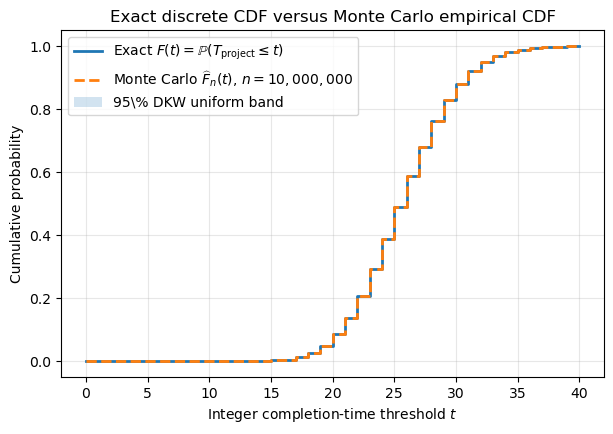

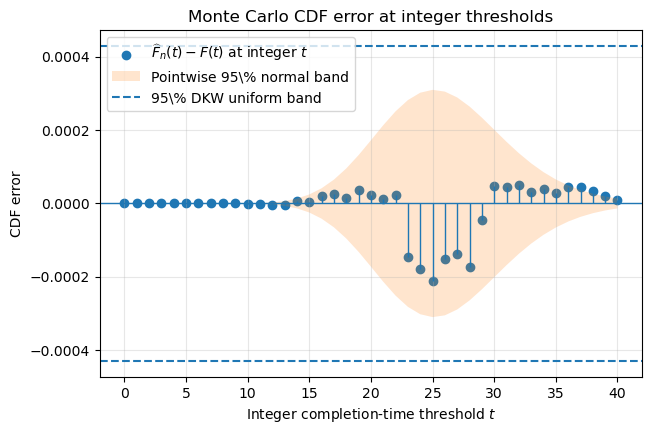

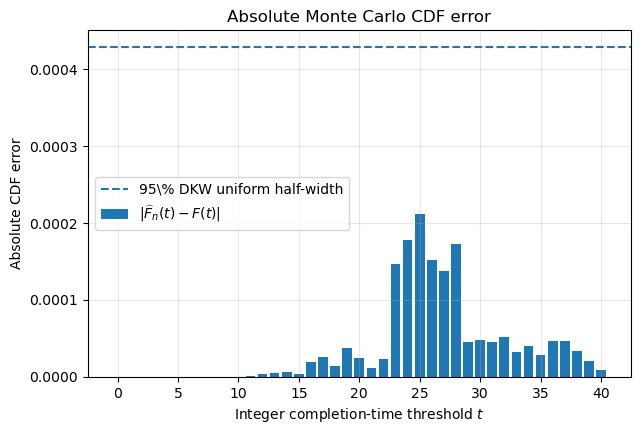

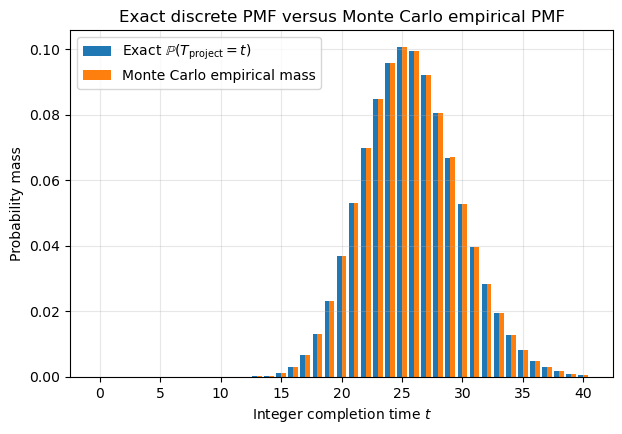

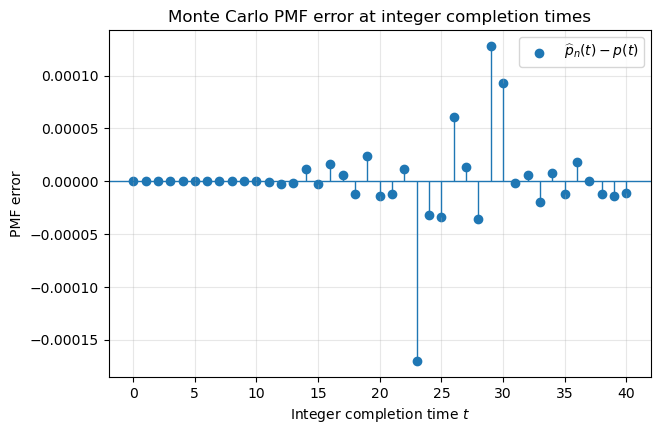

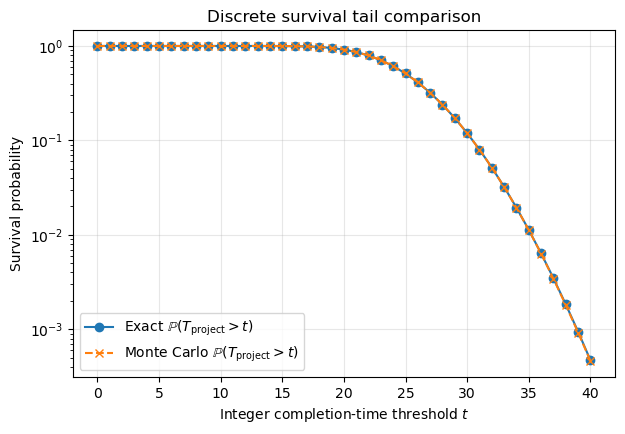

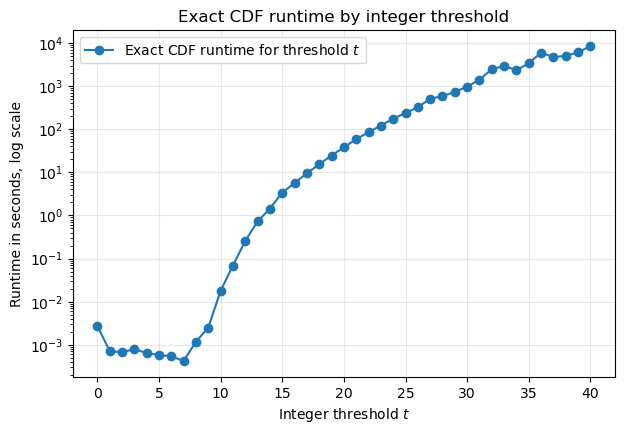

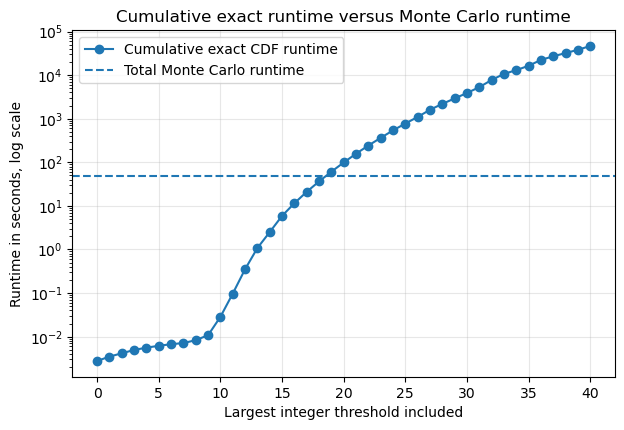



% ------------------------------------------------------------
% LaTeX table: Main validation diagnostics
% ------------------------------------------------------------
\begin{table}
\caption{Monte Carlo validation diagnostics against the exact shifted-Poisson distribution.}
\label{tab:mc_validation_diagnostics}
\begin{tabular}{lr}
\toprule
Metric & Value \\
\midrule
Monte Carlo samples $n$ & 10,000,000 \\
Monte Carlo seed & 2026 \\
Monte Carlo runtime, seconds & 48.6692 \\
Exact CDF runtime, seconds & 46720.2 \\
Runtime ratio, exact / MC & 959.953 \\
Exact CDF grid & $t=0,\ldots,40$ \\
KS distance $\sup_t |\widehat F_n(t)-F(t)|$ & 0.000212389 \\
Integer threshold attaining max CDF error & $t=25$ \\
CDF MAE on integer grid & 3.94731e-05 \\
CDF RMSE on integer grid & 6.85587e-05 \\
95\% DKW half-width & 0.000429469 \\
KS distance / DKW half-width & 0.494538 \\
PMF MAE on integer grid & 1.91493e-05 \\
PMF RMSE on integer grid & 3.96243e-05 \\
PMF total variation on grid & 0.000392562 \

In [2]:
# ------------------------------------------------------------
# Discrete-CDF validation plots and LaTeX tables
# ------------------------------------------------------------
# This cell assumes the first loading/diagnostic cell has already been run.

from textwrap import dedent


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def fmt_float(x: float, digits: int = 6) -> str:
    return f"{x:.{digits}g}"


def save_figure(fig, stem: str) -> None:
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")


def latex_escape_text(s: str) -> str:
    return s.replace("_", r"\_")


# ------------------------------------------------------------
# Discrete-variable diagnostics
# ------------------------------------------------------------
# Since T_project is integer-valued, the meaningful objects are
# P(T_project = t), P(T_project <= t), and P(T_project > t)
# for integer thresholds t.

exact_survival = 1.0 - exact_cdf
mc_survival = 1.0 - mc_cdf

pmf_error = mc_pmf - exact_pmf
abs_pmf_error = np.abs(pmf_error)

pmf_mae = float(abs_pmf_error.mean())
pmf_rmse = float(np.sqrt(np.mean(pmf_error**2)))
pmf_l1_error_on_grid = float(abs_pmf_error.sum())
pmf_total_variation_on_grid = 0.5 * pmf_l1_error_on_grid

cdf_error = mc_cdf - exact_cdf
abs_cdf_error = np.abs(cdf_error)

ks_distance = float(abs_cdf_error.max())
ks_t = int(support[abs_cdf_error.argmax()])

cdf_mae = float(abs_cdf_error.mean())
cdf_rmse = float(np.sqrt(np.mean(cdf_error**2)))

alpha = 0.05
dkw_epsilon = sqrt(log(2 / alpha) / (2 * sample_count))

# Pointwise standard error for the empirical CDF at integer threshold t.
# For each fixed t, 1{T <= t} is Bernoulli(F(t)).
pointwise_se = np.sqrt(exact_cdf * (1.0 - exact_cdf) / sample_count)
pointwise_95_half_width = 1.96 * pointwise_se

mc_tail_mass = float(np.mean(completion_samples > max_t))

pmf_cumsum_consistency_error = float(np.max(np.abs(np.cumsum(exact_pmf) - exact_cdf)))

speedup_exact_over_mc = exact_runtime_total_seconds / mc_runtime_total_seconds

mc_mean = float(np.mean(completion_samples))
mc_sd = float(np.std(completion_samples, ddof=1))
mc_var = float(np.var(completion_samples, ddof=1))

mc_quantiles = {
    0.50: int(np.quantile(completion_samples, 0.50, method="higher")),
    0.75: int(np.quantile(completion_samples, 0.75, method="higher")),
    0.90: int(np.quantile(completion_samples, 0.90, method="higher")),
    0.95: int(np.quantile(completion_samples, 0.95, method="higher")),
    0.99: int(np.quantile(completion_samples, 0.99, method="higher")),
}


# ------------------------------------------------------------
# Figure 1: Exact discrete CDF vs empirical discrete CDF
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

lower_dkw = np.clip(exact_cdf - dkw_epsilon, 0.0, 1.0)
upper_dkw = np.clip(exact_cdf + dkw_epsilon, 0.0, 1.0)

ax.step(
    support,
    exact_cdf,
    where="post",
    linewidth=2,
    label=r"Exact $F(t)=\mathbb{P}(T_{\mathrm{project}}\leq t)$",
)

ax.step(
    support,
    mc_cdf,
    where="post",
    linestyle="--",
    linewidth=2,
    label=rf"Monte Carlo $\widehat F_n(t)$, $n={sample_count:,}$",
)

ax.fill_between(
    support,
    lower_dkw,
    upper_dkw,
    step="post",
    alpha=0.2,
    label=r"95\% DKW uniform band",
)

ax.set_xlabel(r"Integer completion-time threshold $t$")
ax.set_ylabel(r"Cumulative probability")
ax.set_title("Exact discrete CDF versus Monte Carlo empirical CDF")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "01_discrete_cdf_exact_vs_monte_carlo")
plt.show()


# ------------------------------------------------------------
# Figure 2: CDF error at integer thresholds
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.axhline(0.0, linewidth=1)

ax.vlines(
    support,
    0.0,
    cdf_error,
    linewidth=1,
)

ax.scatter(
    support,
    cdf_error,
    label=r"$\widehat F_n(t)-F(t)$ at integer $t$",
)

ax.fill_between(
    support,
    -pointwise_95_half_width,
    pointwise_95_half_width,
    alpha=0.2,
    label=r"Pointwise 95\% normal band",
)

ax.axhline(
    dkw_epsilon,
    linestyle="--",
    label=r"95\% DKW uniform band",
)

ax.axhline(
    -dkw_epsilon,
    linestyle="--",
)

ax.set_xlabel(r"Integer completion-time threshold $t$")
ax.set_ylabel(r"CDF error")
ax.set_title("Monte Carlo CDF error at integer thresholds")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "02_discrete_cdf_error")
plt.show()


# ------------------------------------------------------------
# Figure 3: Absolute CDF error at integer thresholds
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(
    support,
    abs_cdf_error,
    label=r"$|\widehat F_n(t)-F(t)|$",
)

ax.axhline(
    dkw_epsilon,
    linestyle="--",
    label=r"95\% DKW uniform half-width",
)

ax.set_xlabel(r"Integer completion-time threshold $t$")
ax.set_ylabel(r"Absolute CDF error")
ax.set_title("Absolute Monte Carlo CDF error")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "03_absolute_discrete_cdf_error")
plt.show()


# ------------------------------------------------------------
# Figure 4: Exact PMF vs empirical PMF
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

width = 0.40

ax.bar(
    support - width / 2,
    exact_pmf,
    width=width,
    label=r"Exact $\mathbb{P}(T_{\mathrm{project}}=t)$",
)

ax.bar(
    support + width / 2,
    mc_pmf,
    width=width,
    label=r"Monte Carlo empirical mass",
)

ax.set_xlabel(r"Integer completion time $t$")
ax.set_ylabel(r"Probability mass")
ax.set_title("Exact discrete PMF versus Monte Carlo empirical PMF")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "04_discrete_pmf_exact_vs_monte_carlo")
plt.show()


# ------------------------------------------------------------
# Figure 5: PMF error at integer support points
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.axhline(0.0, linewidth=1)

ax.vlines(
    support,
    0.0,
    pmf_error,
    linewidth=1,
)

ax.scatter(
    support,
    pmf_error,
    label=r"$\widehat p_n(t)-p(t)$",
)

ax.set_xlabel(r"Integer completion time $t$")
ax.set_ylabel(r"PMF error")
ax.set_title("Monte Carlo PMF error at integer completion times")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "05_discrete_pmf_error")
plt.show()


# ------------------------------------------------------------
# Figure 6: Survival tail comparison
# ------------------------------------------------------------
tail_mask = (exact_survival > 0.0) | (mc_survival > 0.0)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogy(
    support[tail_mask],
    exact_survival[tail_mask],
    marker="o",
    label=r"Exact $\mathbb{P}(T_{\mathrm{project}}>t)$",
)

ax.semilogy(
    support[tail_mask],
    mc_survival[tail_mask],
    marker="x",
    linestyle="--",
    label=r"Monte Carlo $\mathbb{P}(T_{\mathrm{project}}>t)$",
)

ax.set_xlabel(r"Integer completion-time threshold $t$")
ax.set_ylabel(r"Survival probability")
ax.set_title("Discrete survival tail comparison")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "06_discrete_survival_tail")
plt.show()


# ------------------------------------------------------------
# Figure 7: Exact runtime by threshold, if available
# ------------------------------------------------------------
if exact_runtime_by_t_seconds is not None:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.semilogy(
        support,
        exact_runtime_by_t_seconds,
        marker="o",
        label=r"Exact CDF runtime for threshold $t$",
    )

    ax.set_xlabel(r"Integer threshold $t$")
    ax.set_ylabel(r"Runtime in seconds, log scale")
    ax.set_title("Exact CDF runtime by integer threshold")
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_figure(fig, "07_exact_cdf_runtime_by_threshold")
    plt.show()


# ------------------------------------------------------------
# Figure 8: Cumulative exact runtime vs total MC runtime, if available
# ------------------------------------------------------------
if exact_runtime_by_t_seconds is not None:
    cumulative_exact_runtime = np.cumsum(exact_runtime_by_t_seconds)

    fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.semilogy(
        support,
        cumulative_exact_runtime,
        marker="o",
        label=r"Cumulative exact CDF runtime",
    )

    ax.axhline(
        mc_runtime_total_seconds,
        linestyle="--",
        label=r"Total Monte Carlo runtime",
    )

    ax.set_xlabel(r"Largest integer threshold included")
    ax.set_ylabel(r"Runtime in seconds, log scale")
    ax.set_title("Cumulative exact runtime versus Monte Carlo runtime")
    ax.grid(True, alpha=0.3)
    ax.legend()

    save_figure(fig, "08_cumulative_exact_runtime_vs_monte_carlo")
    plt.show()


# ------------------------------------------------------------
# LaTeX table 1: Main validation diagnostics
# ------------------------------------------------------------
metrics_df = pd.DataFrame(
    [
        [r"Monte Carlo samples $n$", f"{sample_count:,}"],
        [r"Monte Carlo seed", f"{rng_seed}"],
        [r"Monte Carlo runtime, seconds", fmt_float(mc_runtime_total_seconds)],
        [r"Exact CDF runtime, seconds", fmt_float(exact_runtime_total_seconds)],
        [r"Runtime ratio, exact / MC", fmt_float(speedup_exact_over_mc)],
        [r"Exact CDF grid", rf"$t=0,\ldots,{max_t}$"],
        [r"KS distance $\sup_t |\widehat F_n(t)-F(t)|$", fmt_float(ks_distance)],
        [r"Integer threshold attaining max CDF error", rf"$t={ks_t}$"],
        [r"CDF MAE on integer grid", fmt_float(cdf_mae)],
        [r"CDF RMSE on integer grid", fmt_float(cdf_rmse)],
        [r"95\% DKW half-width", fmt_float(dkw_epsilon)],
        [r"KS distance / DKW half-width", fmt_float(ks_distance / dkw_epsilon)],
        [r"PMF MAE on integer grid", fmt_float(pmf_mae)],
        [r"PMF RMSE on integer grid", fmt_float(pmf_rmse)],
        [r"PMF total variation on grid", fmt_float(pmf_total_variation_on_grid)],
        [rf"Exact tail mass $\mathbb{{P}}(T_{{\mathrm{{project}}}}>{max_t})$", fmt_float(exact_tail_mass)],
        [rf"MC tail mass $\mathbb{{P}}(T_{{\mathrm{{project}}}}>{max_t})$", fmt_float(mc_tail_mass)],
        [r"Exact PMF mass on grid", fmt_float(float(exact_pmf.sum()))],
        [r"Max error between cumulative exact PMF and exact CDF", fmt_float(pmf_cumsum_consistency_error)],
    ],
    columns=["Metric", "Value"],
)

metrics_latex = metrics_df.to_latex(
    index=False,
    escape=False,
    column_format="lr",
    caption="Monte Carlo validation diagnostics against the exact shifted-Poisson distribution.",
    label="tab:mc_validation_diagnostics",
)

print("\n\n% ------------------------------------------------------------")
print("% LaTeX table: Main validation diagnostics")
print("% ------------------------------------------------------------")
print(metrics_latex)

with open(TABLE_DIR / "mc_validation_diagnostics.tex", "w", encoding="utf-8") as f:
    f.write(metrics_latex)


# ------------------------------------------------------------
# LaTeX table 2: Selected integer CDF thresholds
# ------------------------------------------------------------
support_index = {int(t): i for i, t in enumerate(support)}

candidate_thresholds = [
    0,
    10,
    15,
    17,
    18,
    20,
    25,
    30,
    33,
    35,
    40,
    max_t,
]

selected_thresholds = []
for t in candidate_thresholds:
    if t in support_index and t not in selected_thresholds:
        selected_thresholds.append(t)

threshold_rows = []

for t in selected_thresholds:
    idx = support_index[t]
    err = cdf_error[idx]
    abs_err = abs_cdf_error[idx]
    half_width = pointwise_95_half_width[idx]

    threshold_rows.append(
        [
            rf"${t}$",
            fmt_float(exact_cdf[idx]),
            fmt_float(mc_cdf[idx]),
            fmt_float(err),
            fmt_float(abs_err),
            fmt_float(half_width),
            "Yes" if abs_err <= dkw_epsilon else "No",
        ]
    )

threshold_df = pd.DataFrame(
    threshold_rows,
    columns=[
        r"$t$",
        r"Exact $F(t)$",
        r"MC $\widehat F_n(t)$",
        r"Error",
        r"Absolute error",
        r"Pointwise 95\% half-width",
        r"Inside DKW band",
    ],
)

threshold_latex = threshold_df.to_latex(
    index=False,
    escape=False,
    column_format="rrrrrrc",
    caption="Exact and Monte Carlo CDF values at selected integer completion-time thresholds.",
    label="tab:selected_discrete_cdf_thresholds",
)

print("\n\n% ------------------------------------------------------------")
print("% LaTeX table: Selected integer CDF thresholds")
print("% ------------------------------------------------------------")
print(threshold_latex)

with open(TABLE_DIR / "selected_discrete_cdf_thresholds.tex", "w", encoding="utf-8") as f:
    f.write(threshold_latex)


# ------------------------------------------------------------
# LaTeX table 3: PMF comparison at the most likely exact completion times
# ------------------------------------------------------------
top_k = min(12, len(support))
top_pmf_indices = np.argsort(exact_pmf)[-top_k:][::-1]

pmf_rows = []

for idx in top_pmf_indices:
    t = int(support[idx])
    pmf_rows.append(
        [
            rf"${t}$",
            fmt_float(exact_pmf[idx]),
            fmt_float(mc_pmf[idx]),
            fmt_float(pmf_error[idx]),
            fmt_float(abs_pmf_error[idx]),
        ]
    )

pmf_df = pd.DataFrame(
    pmf_rows,
    columns=[
        r"$t$",
        r"Exact $p(t)$",
        r"MC $\widehat p_n(t)$",
        r"Error",
        r"Absolute error",
    ],
)

pmf_latex = pmf_df.to_latex(
    index=False,
    escape=False,
    column_format="rrrrr",
    caption="Exact and Monte Carlo probability masses at the most likely integer completion times.",
    label="tab:selected_discrete_pmf_values",
)

print("\n\n% ------------------------------------------------------------")
print("% LaTeX table: Selected PMF values")
print("% ------------------------------------------------------------")
print(pmf_latex)

with open(TABLE_DIR / "selected_discrete_pmf_values.tex", "w", encoding="utf-8") as f:
    f.write(pmf_latex)


# ------------------------------------------------------------
# LaTeX table 4: Completion-time summary statistics
# ------------------------------------------------------------
summary_df = pd.DataFrame(
    [
        [r"MC mean $\widehat{\mathbb{E}}[T_{\mathrm{project}}]$", fmt_float(mc_mean)],
        [r"MC variance", fmt_float(mc_var)],
        [r"MC standard deviation", fmt_float(mc_sd)],
        [r"MC median", rf"${mc_quantiles[0.50]}$"],
        [r"MC 75\% quantile", rf"${mc_quantiles[0.75]}$"],
        [r"MC 90\% quantile", rf"${mc_quantiles[0.90]}$"],
        [r"MC 95\% quantile", rf"${mc_quantiles[0.95]}$"],
        [r"MC 99\% quantile", rf"${mc_quantiles[0.99]}$"],
    ],
    columns=["Quantity", "Value"],
)

summary_latex = summary_df.to_latex(
    index=False,
    escape=False,
    column_format="lr",
    caption="Monte Carlo summary statistics for the discrete project completion time.",
    label="tab:completion_time_summary",
)

print("\n\n% ------------------------------------------------------------")
print("% LaTeX table: Completion-time summary statistics")
print("% ------------------------------------------------------------")
print(summary_latex)

with open(TABLE_DIR / "completion_time_summary.tex", "w", encoding="utf-8") as f:
    f.write(summary_latex)


# ------------------------------------------------------------
# LaTeX table 5: Contract-risk quantities
# ------------------------------------------------------------
contract_target = 17
penalty_per_day = 100
bonus_if_on_time = 500

prob_on_time = float(np.mean(completion_samples <= contract_target))
prob_late = float(np.mean(completion_samples > contract_target))

delay_beyond_target = np.maximum(completion_samples - contract_target, 0)

expected_delay = float(np.mean(delay_beyond_target))
expected_penalty = penalty_per_day * expected_delay
expected_bonus = bonus_if_on_time * prob_on_time
expected_net_adjustment = expected_bonus - expected_penalty

contract_df = pd.DataFrame(
    [
        [r"Contract target", rf"${contract_target}$ days"],
        [rf"MC $\mathbb{{P}}(T_{{\mathrm{{project}}}}\leq {contract_target})$", fmt_float(prob_on_time)],
        [rf"MC $\mathbb{{P}}(T_{{\mathrm{{project}}}}>{contract_target})$", fmt_float(prob_late)],
        [rf"MC $\mathbb{{E}}[(T_{{\mathrm{{project}}}}-{contract_target})^+]$", fmt_float(expected_delay)],
        [r"Expected penalty", rf"\${expected_penalty:,.2f}"],
        [r"Expected bonus", rf"\${expected_bonus:,.2f}"],
        [r"Expected net contract adjustment", rf"\${expected_net_adjustment:,.2f}"],
    ],
    columns=["Quantity", "Value"],
)

contract_latex = contract_df.to_latex(
    index=False,
    escape=False,
    column_format="lr",
    caption="Monte Carlo estimates of contract-related schedule risk.",
    label="tab:contract_risk_metrics",
)

print("\n\n% ------------------------------------------------------------")
print("% LaTeX table: Contract-risk quantities")
print("% ------------------------------------------------------------")
print(contract_latex)

with open(TABLE_DIR / "contract_risk_metrics.tex", "w", encoding="utf-8") as f:
    f.write(contract_latex)


# ------------------------------------------------------------
# Save CSV versions too
# ------------------------------------------------------------
metrics_df.to_csv(TABLE_DIR / "mc_validation_diagnostics.csv", index=False)
threshold_df.to_csv(TABLE_DIR / "selected_discrete_cdf_thresholds.csv", index=False)
pmf_df.to_csv(TABLE_DIR / "selected_discrete_pmf_values.csv", index=False)
summary_df.to_csv(TABLE_DIR / "completion_time_summary.csv", index=False)
contract_df.to_csv(TABLE_DIR / "contract_risk_metrics.csv", index=False)


# ------------------------------------------------------------
# Final output summary
# ------------------------------------------------------------
print("\nSaved figures to:")
print(FIG_DIR.resolve())

print("\nSaved LaTeX and CSV tables to:")
print(TABLE_DIR.resolve())

print("\nKey diagnostics:")
print(f"KS distance: {ks_distance:.6g}")
print(f"95% DKW half-width: {dkw_epsilon:.6g}")
print(f"KS / DKW: {ks_distance / dkw_epsilon:.6g}")
print(f"CDF MAE: {cdf_mae:.6g}")
print(f"CDF RMSE: {cdf_rmse:.6g}")
print(f"PMF total variation on grid: {pmf_total_variation_on_grid:.6g}")
print(f"Runtime ratio exact / MC: {speedup_exact_over_mc:.6g}")